<a href="https://colab.research.google.com/github/riyoprayogi/MNIST/blob/main/MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"riyorizkyprayogi","key":"37e4606602e37425796b5a6de4f9d3cd"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
#Tesst API
!kaggle datasets list

ref                                                                 title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
------------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
algozee/teenager-menthal-healy                                      Social Media Impact on Teen Mental Health                16190  2026-04-05 08:04:21.823000          13040        283                1  
syedaeman2212/shoes-sales-dataset                                   Shoes Sales Dataset                                      18813  2026-04-23 16:28:33.087000            651         25                1  
nafeesalmahadi/superstore-sales-analytics-dataset-2026              Superstore Sales Analytics Dataset - 2026              3347509  2026-04-23 14:43:55.677000            824         26

In [ ]:
!kaggle datasets download -d scolianni/mnistasjpg

Dataset URL: https://www.kaggle.com/datasets/scolianni/mnistasjpg
License(s): CC0-1.0
100% 68.4M/68.4M [00:00<00:00, 163MB/s]



In [ ]:
import zipfile
import tarfile

# Unzip the downloaded file
with zipfile.ZipFile("mnistasjpg.zip", 'r') as zip_ref:
    zip_ref.extractall()

# Now extract the gzipped tar files
with tarfile.open("trainingSet.tar.gz", "r:gz") as tar:
    tar.extractall()

with tarfile.open("testSet.tar.gz", "r:gz") as tar:
    tar.extractall()

/tmp/ipykernel_2321/2307896814.py:10: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall()
/tmp/ipykernel_2321/2307896814.py:13: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall()


In [49]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torch.utils.data import random_split, DataLoader

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((28,28)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load dataset
full_dataset = datasets.ImageFolder(root='trainingSet', transform=transform)

# Split 80:20
train_size = int(0.8 * len(full_dataset))
val_size   = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# DataLoader
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False)

In [ ]:
import shutil

shutil.rmtree("trainingSet/trainingSet", ignore_errors=True)

In [35]:
import os
print(os.listdir("trainingSet"))

['9', '1', '7', '5', '3', '0', '8', '4', '6', '2']


In [36]:
from torchvision import datasets

train_dataset = datasets.ImageFolder(root='trainingSet', transform=transform)

print(train_dataset.classes)
print(len(train_dataset.classes))

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
10


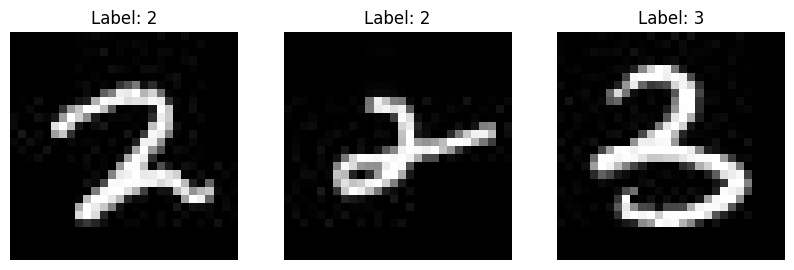

In [37]:
import random
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(10, 3))

for i in range(3):
    idx = random.randint(0, len(train_dataset)-1)
    img, label = train_dataset[idx]

    axes[i].imshow(img.squeeze(), cmap='gray')
    axes[i].set_title(f"Label: {label}")
    axes[i].axis('off')

plt.show()

# Model

In [38]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MNIST_CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)

        self.pool = nn.MaxPool2d(2,2)

        self.fc1 = nn.Linear(64*7*7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        x = x.view(-1, 64*7*7)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

Test ada error folder tadi

In [39]:
print(train_dataset.classes)
print(len(train_dataset.classes))

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
10


In [40]:
import os

print(os.listdir("trainingSet"))

['9', '1', '7', '5', '3', '0', '8', '4', '6', '2']


In [41]:
print(os.path.exists("trainingSet/trainingSet"))

False


# Train


In [42]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MNIST_CNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Re-initialize train_dataset and test_dataset to ensure they reflect any previous directory cleanups.
train_dataset = datasets.ImageFolder(root='trainingSet', transform=transform)
test_dataset = datasets.ImageFolder(root='testSet', transform=transform)

# Re-create data loaders to ensure they use the latest (and correctly structured) datasets.
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Dynamically get the number of classes from the dataset
num_classes = len(train_dataset.classes)

# Adjust the model's final layer if the number of output features doesn't match
if model.fc2.out_features != num_classes:
    print(f"Adjusting model's final layer from {model.fc2.out_features} to {num_classes} classes.")
    model.fc2 = nn.Linear(model.fc2.in_features, num_classes).to(device)
    # Reinitialize optimizer as model parameters have changed
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(5):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

Epoch 1, Loss: 0.1978
Epoch 2, Loss: 0.0510
Epoch 3, Loss: 0.0357
Epoch 4, Loss: 0.0257
Epoch 5, Loss: 0.0178


In [44]:
correct = 0
total = 0

model.eval()
with torch.no_grad():
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Train Accuracy: {100 * correct / total:.2f}%")

Train Accuracy: 99.53%


# Confusin Matrix


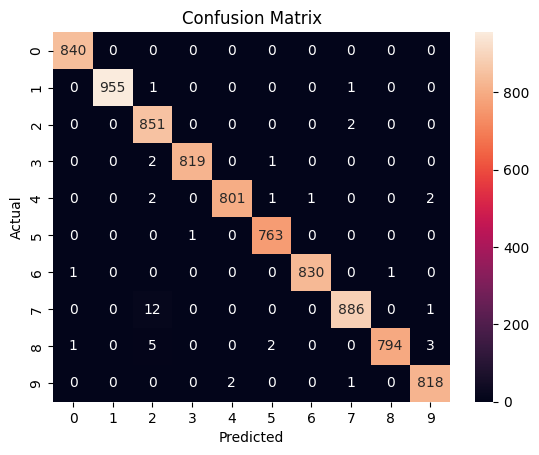

In [50]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [51]:
from sklearn.metrics import classification_report

print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       840
           1       1.00      1.00      1.00       957
           2       0.97      1.00      0.99       853
           3       1.00      1.00      1.00       822
           4       1.00      0.99      1.00       807
           5       0.99      1.00      1.00       764
           6       1.00      1.00      1.00       832
           7       1.00      0.99      0.99       899
           8       1.00      0.99      0.99       805
           9       0.99      1.00      0.99       821

    accuracy                           0.99      8400
   macro avg       0.99      0.99      0.99      8400
weighted avg       0.99      0.99      0.99      8400

